# INTRODUCTION

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">


The rapid growth of e-commerce platforms has generated vast amounts of product-related data that can provide valuable insights into customer preferences, pricing strategies, and market trends. Amazon, being one of the world's largest online marketplaces, offers a diverse range of products that vary in price, popularity, ratings, discounts, and promotional strategies.

This Exploratory Data Analysis (EDA) project analyzes the Amazon Products Sales Dataset (2025), which contains information on more than 42,000 Amazon product listings. The dataset includes key attributes such as product ratings, customer reviews, recent purchase counts, pricing details, discounts, Best Seller status, sponsored listings, coupon availability, delivery information, and sustainability badges.

The primary goal of this analysis is to perform data cleaning & wraggling and explore patterns within product listings and understand the factors that influence product popularity and customer engagement. Through data visualization and statistical analysis, the project aims to uncover relationships among pricing, ratings, reviews, discounts, and promotional features. The insights derived from this dataset can help in understanding consumer behavior, evaluating product performance, and identifying trends in the competitive e-commerce marketplace.
</div>


# OBJECTIVES:

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>To perform data cleaning and wraggling to handle missing values, inconsistent and non standard values.
<li>To understand the overall structure and distribution of Amazon product listings.
<li>To analyze product pricing patterns, including current prices, listed prices, and discount trends.
<li> To examine customer ratings and review distributions across products.
<li>To identify factors associated with product popularity using recent purchase counts and customer engagement metrics.
<li>To investigate the relationship between pricing, discounts, ratings, and the number of reviews.
<li>To analyze the impact of promotional features such as Best Seller status, sponsored listings, and coupon availability on product performance.
<li>To explore product availability and delivery-related information to identify potential purchasing trends.
<li>To examine sustainability badges and their prevalence across Amazon products.
<li> To detect outliers and unusual patterns within pricing, ratings, and purchasing behavior.
<li>To generate meaningful visualizations that communicate key insights from the dataset effectively.
<li>To provide data-driven observations that can support business intelligence, market analysis, and future predictive modeling projects.
</ul>
</div>


<div>

# 1. Getting Ready with Dataset

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import re
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects 



In [2]:
data = pd.read_csv('/home/kartika/Datasets/amazonsalesdata.csv')
data.head()

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6 out of 5 stars,"35,882",10K+ bought in past month,NaN,basic variant price: $162.24,No Discount,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,21-08-2025 11:14
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8 out of 5 stars,"28,988",10K+ bought in past month,NaN,basic variant price: $72.74,No Discount,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,21-08-2025 11:14


In [3]:
data.tail()

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0 out of 5 stars,1,100+ bought in past month,195.99,basic variant price: nan,No Discount,No Badge,Organic,No Coupon,NaN,"FREE delivery Thu, Sep 4Or fastest delivery Tu...",NaN,https://m.media-amazon.com/images/I/51KCB+egEs...,/Elgato-4K-Pro-Internal-Capture/dp/B0DLR3WQWR/...,30-08-2025 19:56
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2 out of 5 stars,20,200+ bought in past month,89.99,basic variant price: $25.00 off coupon applied,No Discount,No Badge,Organic,Save $25.00 with coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery Mo...",NaN,https://m.media-amazon.com/images/I/51jV+o1LZE...,/Arlo-Essential-Spotlight-Camera-Surveillance/...,30-08-2025 19:56
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3 out of 5 stars,57,50+ bought in past month,899.99,basic variant price: Lowest price in 30 days,"$1,099.99",Save 18%,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery We...",NaN,https://m.media-amazon.com/images/I/71ySPkNLkG...,/GIGABYTE-FO32U2-32-3840x2160-240Hz-FreeSync-A...,30-08-2025 19:56
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7 out of 5 stars,"7,102",500+ bought in past month,10.39,basic variant price: nan,$15.98,No Badge,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4 on $35 of items shipp...",NaN,https://m.media-amazon.com/images/I/411c0JFJ79...,/Monoprice-XLR-Male-4-Inch-Cable/dp/B001UJEKZ6...,30-08-2025 19:56
42674,Lorex Fusion 1080p HD Security Camera System w...,4.4 out of 5 stars,75,50+ bought in past month,419.99,basic variant price: nan,$499.99,No Badge,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery We...",NaN,https://m.media-amazon.com/images/I/71wTn+zoSr...,/Lorex-8-Channel-Security-Outdoor-Cameras/dp/B...,30-08-2025 19:56


<div>

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Title                     42675 non-null  object
 1   Rating                    41651 non-null  object
 2   Number_of_reviews         41651 non-null  object
 3   bought_in_last_month      39458 non-null  object
 4   Current/discounted_price  30926 non-null  object
 5   Price_on_variant          42675 non-null  object
 6   Listed_price              42675 non-null  object
 7   is_best_seller            42675 non-null  object
 8   is_sponsored              42675 non-null  object
 9   is_couponed               42675 non-null  object
 10  buy_box_availability      28022 non-null  object
 11  delivery_details          30955 non-null  object
 12  sustainability_badges     3408 non-null   object
 13  image_url                 42675 non-null  object
 14  product_url           

<div>

# 2. Data Cleaning and Wraggling

In [5]:
data.drop(columns = ['image_url', 'product_url', 'collected_at', 'Price_on_variant'], inplace = True)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Dropped irrelevant columns for this analysis.

In [6]:
data.rename(columns = {
    'Title' : 'title',
    'Rating': 'rating',
    'Number_of_reviews' : 'reviews',
    'Current/discounted_price' : 'selling_price',
    'Listed_price' : 'listed_price'

}, inplace = True)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Renamed some columns.

<div>

## 2.1 Rating Field

In [7]:
data['rating'].unique()

array(['4.6 out of 5 stars', '4.3 out of 5 stars', '4.8 out of 5 stars',
       '4.5 out of 5 stars', '4.0 out of 5 stars', '4.7 out of 5 stars',
       '4.2 out of 5 stars', '4.4 out of 5 stars', '4.1 out of 5 stars',
       '4.9 out of 5 stars', '3.9 out of 5 stars', '3.8 out of 5 stars',
       '2.8 out of 5 stars', '3.6 out of 5 stars', '3.7 out of 5 stars',
       '3.4 out of 5 stars', '3.5 out of 5 stars', nan,
       '5.0 out of 5 stars', '3.3 out of 5 stars', '2.4 out of 5 stars',
       '2.9 out of 5 stars', '3.2 out of 5 stars', '3.0 out of 5 stars',
       '1.0 out of 5 stars', '2.3 out of 5 stars', '3.1 out of 5 stars',
       '2.5 out of 5 stars', '2.7 out of 5 stars', '1.5 out of 5 stars',
       '2.6 out of 5 stars', '2.0 out of 5 stars'], dtype=object)

In [8]:
data['rating_category'] = data['rating'].fillna('Unknown')

In [9]:
data['rating_num'] = data['rating'].str.extract(r'(\d+\.\d+|\d+)').astype(float)

In [10]:
data['rating_num'] = data['rating_num'].fillna(data['rating_num'].median())

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Kept, original column as it is and replaced nan with unknown for categorical analysis and visualization.
<br>
For numerical column, filled missing values with median rating.

<div>

## 2.2 Reviews Field

In [11]:
cleaned_str = data['reviews'].astype(str).str.replace(',', '', regex=False).str.extract(r'(\d+)')[0]


data['reviews'] = pd.to_numeric(cleaned_str, errors='coerce').astype('Int64')

data['reviews'] = data['reviews'].fillna(data['reviews'].median())

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Review field contained values seperated by , , will is not suitable for statistical analysis and visualization. Hence, extracted numeric values and filled null with median review.

<div>

## 2.3 Last Month Purchase Field

In [12]:
extracted = data['bought_in_last_month'].astype(str).str.extract(
    r'(\d+(?:\.\d+)?)\s*(K)?(?:\+|$)')


num = extracted[0].astype(float)
multiplier = extracted[1].str.upper().map({'K': 1000}).fillna(1)


data['bought_in_last_month'] = (num * multiplier).astype('Int64')

data['bought_in_last_month'].describe()

count        32165.0
mean     1293.625369
std      6318.229407
min             10.0
25%            100.0
50%            200.0
75%            400.0
max         100000.0
Name: bought_in_last_month, dtype: Float64

In [13]:
data['bought_in_last_month'] = data['bought_in_last_month'].fillna(0)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>Text values included shorthand multipliers (e.g., '6K+', '100K+').Non-sales strings (e.g., 'List Price:', 'ESRB Rating:', This product is certified by Amazon to work with Alexa. This product can be controlled with your voice through Alexa-enabled devices such as Amazon Echo and Amazon Tap.) were trapped in the column. Products without sales badges appeared as NaN.
<li>Parsed digits and unit indicators (K) using r'(\d+(?:\.\d+)?)\s*(K)?(?:\+|$)' and scaled values with 'K' by $1,000$ (e.g., $6\text{K} \rightarrow 6,000$) and filtered out non-matching noise to NaN.
<br>
<li>Finally filled all missing values (NaN) with 0 to reflect products selling below the platform's public display threshold ($<50$ sales/month).
</ul>
</div>

<div>

## 2.4 List and Selling Price Field

In [14]:

data['listed_price_numeric'] = (
    data['listed_price']
    .replace('No Discount', np.nan)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [15]:
data['discount_status'] = np.where(
    data['listed_price_numeric'].isnull(),
    'No Discount',
    'Discount Available'
)

In [16]:
data['discount_status'].value_counts()

discount_status
No Discount           30364
Discount Available    12311
Name: count, dtype: int64

In [17]:
data['selling_price'] = pd.to_numeric(data['selling_price'], errors = 'coerce')

In [18]:
data['selling_price'].skew()

np.float64(2.3211730119644196)

In [19]:
data['selling_price'] = data['selling_price'].fillna(data['selling_price'].median())

In [20]:
data['selling_price'].describe()

count    42675.000000
mean       124.052808
std        169.155139
min          2.490000
25%         38.045000
50%         69.950000
75%        119.990000
max        999.990000
Name: selling_price, dtype: float64

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Cleaning & Conversion
<ul>
<li>Removed $ and , from listed_price and converted listed_price to numeric float, safely turning text like 'No Discount' into NaN.
<li>Created new column called discount_status from the listed_price column where values were null due to text like 'No Discount'.
<li>Converted selling price to numeric form and imputed null values with median price.

</ul>
</div>

<div>

## 2.5 Is Best Seller Field

In [21]:
data['is_best_seller'].value_counts(dropna=False)

is_best_seller
No Badge             40814
Amazon's               744
Limited time deal      409
Best Seller            275
Save 30%               125
Ends in                 97
Save 10%                61
Save 18%                57
Save 17%                51
Save 12%                26
Save 9%                 14
Save 77%                 2
Name: count, dtype: int64

In [22]:
data['best_seller'] = data['is_best_seller'].eq('Best Seller').map({True: 'Best Seller', False: 'Not Best Seller'})
data['best_seller'].value_counts(dropna=False)

best_seller
Not Best Seller    42400
Best Seller          275
Name: count, dtype: int64

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Creater new column from is_best_seller, to determine the best seller and not best seller product.

<div>

## 2.6 Is Sponsered and Couponed Field

In [23]:
data.is_sponsored.value_counts(dropna=False)

is_sponsored
Organic      35664
Sponsored     7011
Name: count, dtype: int64

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">No null or inconsistent values.

<div>

In [24]:
data['is_couponed'] = (
    data['is_couponed']
    .astype('string')
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.replace(r'\s*\(some sizes/colors\)', '', regex=True)
)

In [25]:
data['coupon_status'] = np.select(
    [
        data['is_couponed'].eq('No Coupon'),
        data['is_couponed'].str.contains(r'Save\s+\$', na=False),
        data['is_couponed'].str.contains(r'Save\s+\d+(?:\.\d+)?%', na=False),
        data['is_couponed'].isna()
    ],
    [
        'No Coupon',
        'Free Dollar Coupon',
        'Discount Coupon',
        'Unknown'
    ],
    default='Unknown'
)

In [26]:
data['coupon_status'].value_counts(dropna=False)

coupon_status
No Coupon             40727
Discount Coupon        1061
Free Dollar Coupon      887
Name: count, dtype: int64

<div>

# 2.7 Delivery Details Field

In [27]:

def parse_delivery_info(val):
    if pd.isna(val) or val == 'Ships to Pakistan':
        return pd.Series([None, 0, None, None])
    
    val = str(val)
    
    
    if 'FREE' in val:
        fee = 0.0
    else:
        fee_match = re.search(r'\$(\d+\.\d+)', val)
        fee = float(fee_match.group(1)) if fee_match else None
        
    
    has_free_shipping = 1 if ('FREE' in val or fee == 0.0) else 0
    
  
    parts = re.split(r'Or fastest delivery', val)
    standard_part = parts[0]
    fastest_part = parts[1] if len(parts) > 1 else None
    
    return pd.Series([fee, has_free_shipping, standard_part.strip(), fastest_part])


data[['shipping_fee', 'is_free_shipping', 'standard_delivery_text', 'fastest_delivery_text']] = \
    data['delivery_details'].apply(parse_delivery_info)

In [28]:
data['shipping_fee'] = data['shipping_fee'].fillna(data['shipping_fee'].median())

data['is_free_shipping'] = data['is_free_shipping'].fillna(0).astype(int)
data['is_free_shipping'] = data['is_free_shipping'].replace({0: 'No', 1: 'Yes'})




<div>

## 2.8 Remaing Fields

In [29]:
data['buy_box_availability'] = data['buy_box_availability'].fillna('Unavailable')

In [30]:
data['buy_box_availability'].value_counts(dropna = False)

buy_box_availability
Add to cart    28022
Unavailable    14653
Name: count, dtype: int64

<div>

In [31]:
data['sustainability_badges'] = data['sustainability_badges'].fillna('No Badge')

In [32]:
tech_badges = ['Works with Alexa', 'Alexa Built-in']


data['sustainability_badges'] = data['sustainability_badges'].apply(
    lambda x: 'None' if x in tech_badges else x
)

<div>


<div>

# 3. Univariate Analysis

## 3.1 Product Performance Metrices

In [33]:
data['rating_num'].describe()

count    42675.000000
mean         4.401844
std          0.382636
min          1.000000
25%          4.200000
50%          4.500000
75%          4.600000
max          5.000000
Name: rating_num, dtype: float64

In [34]:
data['rating_num'].skew()

np.float64(-1.873667498112037)

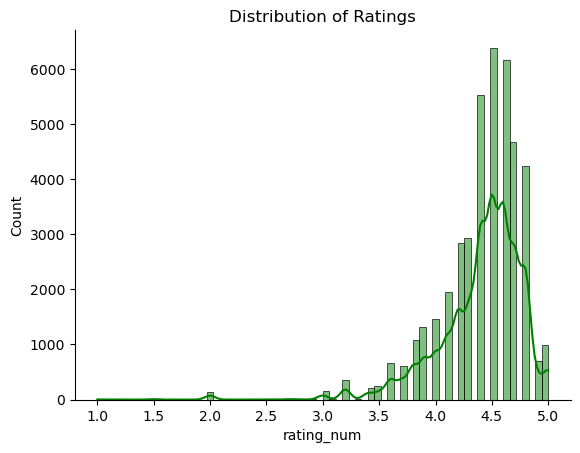

In [35]:
sns.histplot(
    data = data,
    x = 'rating_num',
    bins = 70,
    color = 'green',
    kde = True
)

sns.despine()
plt.title('Distribution of Ratings')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The rating distribution is heavily negatively skewed, most of the products have medium to high rating, while few have very low rating.

<div>

In [36]:
data['reviews'].describe()

count         42675.0
mean      3021.260316
std      12880.020115
min               1.0
25%              84.0
50%             343.0
75%            1825.5
max          865598.0
Name: reviews, dtype: Float64

In [37]:
data['reviews'].skew()

np.float64(24.616107530394153)

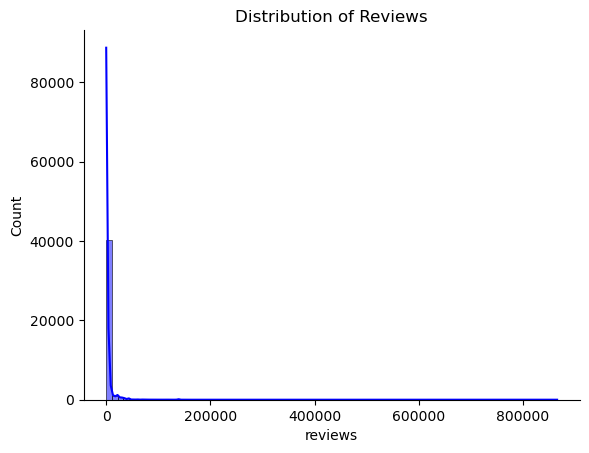

In [38]:
sns.histplot(
    data = data,
    x = 'reviews',
    bins = 79,
    color = 'blue',
    kde = True
)

plt.title(
    'Distribution of Reviews'
)
sns.despine()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The review distribution is extremely positively skewed, majority of the products have reviews less than 2000. Few products have very high number of reviews.

<div>

In [39]:
data['bought_in_last_month'].describe()

count       42675.0
mean     975.031283
std       5513.5229
min             0.0
25%            50.0
50%           100.0
75%           300.0
max        100000.0
Name: bought_in_last_month, dtype: Float64

In [40]:
data['bought_in_last_month'].skew()

np.float64(12.333560521715443)

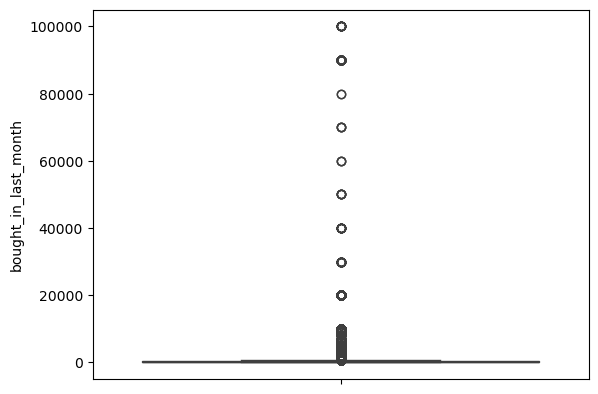

In [41]:
sns.boxplot(
    data = data,
    y = 'bought_in_last_month',

)

plt.show()

In [42]:
group = data.groupby('bought_in_last_month').size().reset_index(name='count')

In [43]:
group.sort_values(by='bought_in_last_month', ascending=False).head(10)

,bought_in_last_month,count
30,100000,13
29,90000,92
28,80000,2
27,70000,4
26,60000,3
25,50000,6
24,40000,14
23,30000,28
22,20000,772
21,10000,229


<div>

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">There are 13 products with over 10000 sold in the last month.

<div>

## 3.2 Pricing Variables

In [45]:
data['selling_price'].describe()

count    42675.000000
mean       124.052808
std        169.155139
min          2.490000
25%         38.045000
50%         69.950000
75%        119.990000
max        999.990000
Name: selling_price, dtype: float64

In [46]:
data['selling_price'].skew()

np.float64(2.988103331894081)

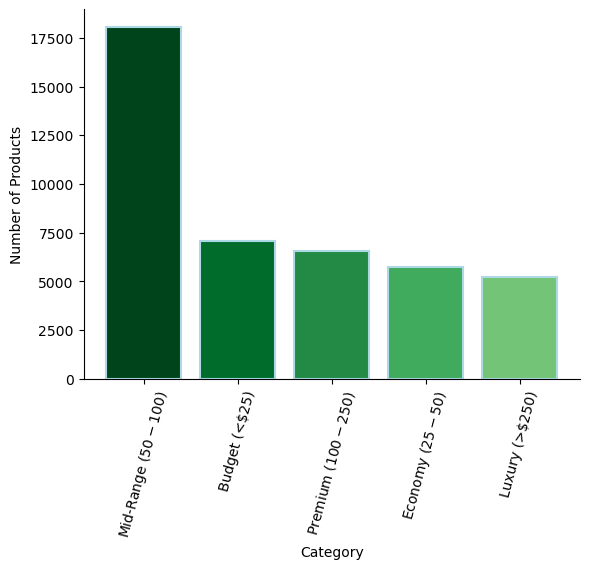

In [53]:

bins = [0, 25, 50, 100, 250, np.inf]
labels = [
    "Budget (<$25)",
    "Economy ($25-$50)",
    "Mid-Range ($50-$100)",
    "Premium ($100-$250)",
    "Luxury (>$250)",
]

data["selling_price_category"] = pd.cut(data["selling_price"], bins=bins, labels=labels)


plt.bar(
    x = data['selling_price_category'].value_counts().index,
    height = data['selling_price_category'].value_counts().values,
    color = plt.cm.Greens(np.linspace(1, 0.5, 5)),
    linewidth = 1.5,
    edgecolor = 'lightblue'
)


plt.xlabel('Category')
plt.ylabel('Number of Products')
sns.despine()
plt.xticks(rotation = 75)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Most of the products have mid-range price, costing from 50$ to 100$.


<div>

In [62]:
data['discount_status'].value_counts()

discount_status
No Discount           30364
Discount Available    12311
Name: count, dtype: int64

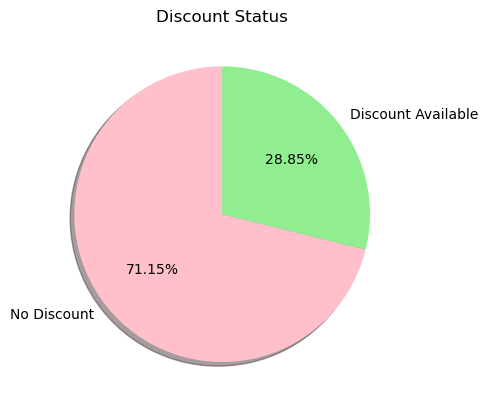

In [65]:
plt.pie(
    data['discount_status'].value_counts().values,
    labels = data['discount_status'].value_counts().index,
    autopct = '%1.2f%%',
    colors = ['pink', 'lightgreen'],
    startangle = 90,
    shadow = True
)

plt.title('Discount Status')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Majority of the products do not offer any kind of discount.

<div>

<div>

# 3.3 Product Status Flags